# Import

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import pandas as pd
import numpy as np

from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from torch.utils.data import Dataset, DataLoader, Subset
from torch.utils.tensorboard import SummaryWriter

import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.formatting.rule import ColorScaleRule

from dataset_classes import SH_Dataset

from models_with_temporal_graph import (
    GLFN_TC_Attention,
    GLFN_TC_GlobalLocal,
    GLFN_TC_Linear,
    GLFN_TC_MultiScale,
)

## Import Training and Testing Loops

In [2]:
from helper_functions_trial import train_model, test_model,  validate

In [3]:
import traceback
import os

In [4]:
#reproducibility and baseline
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

# Sensitivity target model
SENSITIVITY_MODEL_CLS = GLFN_TC_MultiScale

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️ Device: {device}")

dataset = SH_Dataset(
    csv_path=r"sh_dataset.csv",
    T_in=72,
    T_out=240,
    lag_hours=[1, 12, 24, 168],
    rolling_windows=[12, 24],
)

# ------------------------------------------------------------
# RAW split sizes
# ------------------------------------------------------------
total_len = len(dataset.df_numeric)

train_split_idx = int(0.6 * total_len)
val_split_idx   = int(0.8 * total_len)

print(f"📊 Raw rows       : {total_len}")
print(f"📊 Train raw end  : {train_split_idx}")
print(f"📊 Val raw end    : {val_split_idx}")

# ------------------------------------------------------------
# Fit scaler ONLY on training region
# ------------------------------------------------------------
scaler = StandardScaler()
scaler.fit(
    dataset.df_numeric.iloc[:train_split_idx]
    .values.astype(np.float32)
)
dataset.apply_scaler(scaler)
dataset.scaler = scaler

# ------------------------------------------------------------
# Effective sample ranges (non-contiguous to prevent leakage)
# ------------------------------------------------------------
effective_len = len(dataset)

train_end  = min(train_split_idx - dataset.T_in - dataset.T_out, effective_len)
val_start  = train_split_idx - dataset.T_in
val_end    = min(val_split_idx  - dataset.T_in - dataset.T_out, effective_len)
test_start = val_split_idx - dataset.T_in

train_idx = range(0, train_end)
val_idx   = range(val_start, val_end)
test_idx  = range(test_start, effective_len)

print(f"📦 Effective samples : {effective_len}")
print(f"📦 Train samples     : {len(train_idx)}")
print(f"📦 Val samples       : {len(val_idx)}")
print(f"📦 Test samples      : {len(test_idx)}")

# ------------------------------------------------------------
# Subsets + loaders
# ------------------------------------------------------------
train_subset = Subset(dataset, train_idx)
val_subset   = Subset(dataset, val_idx)
test_subset  = Subset(dataset, test_idx)

BATCH_SIZE = 64

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_subset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_subset,  batch_size=BATCH_SIZE, shuffle=False)

print(
    f"\n🚚 DataLoaders ready | "
    f"Train batches: {len(train_loader)} | "
    f"Val batches: {len(val_loader)} | "
    f"Test batches: {len(test_loader)}"
)

🖥️ Device: cuda
Loaded dataset with 27 features (target=load), total rows=17258
📊 Raw rows       : 17258
📊 Train raw end  : 10354
📊 Val raw end    : 13806
📦 Effective samples : 16946
📦 Train samples     : 10042
📦 Val samples       : 3212
📦 Test samples      : 3212

🚚 DataLoaders ready | Train batches: 157 | Val batches: 51 | Test batches: 51


In [6]:
import os
import time
import math
import json
import random

RUN_NAME = "TR_GNN_SH_Multi_Scale"

SAVE_DIR = "Sensitivity_Analysis_SH"
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_SAVE_DIR = os.path.join(SAVE_DIR, "best_models")
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

FIG_DIR = os.path.join(SAVE_DIR, "loss_curves")
os.makedirs(FIG_DIR, exist_ok=True)

print(f"📁 Save dir: {SAVE_DIR}")

BASE_HPARAMS = dict(
    N=dataset.N,
    T_in=72,
    T_out=240,
    d=32,

    hidden_dim=64,
    GCN_Layer=5,

    kernel_size=7,
    dilation=3,

    dropout_forecast=0.1,
    dropout_gcn=0.2,
    dropout_temporal=0.2,

    lr=1e-4,
    scheduler_patience=3,
    weight_decay=1e-4,

    epochs=100,

    lambda_smooth=0.01,
    lambda_sparse=1e-4,
)

BASELINE_CONFIG_NAME = "baseline"
BASELINE_CONFIG = dict(
    GCN_Layer=5,
    hidden_dim=64,
    kernel_size=7,
    dilation=3
)

BASELINE_VAL_LOSS = float("inf")

# ------------------------------------------------------------
# Build experiments list  (name, full-hparam-dict)
# ------------------------------------------------------------
experiments = []

# ------------------------------------------------------------
# 0. TRUE BASELINE RUN
# ------------------------------------------------------------
baseline_cfg = BASE_HPARAMS.copy()

baseline_cfg["GCN_Layer"] = 5
baseline_cfg["hidden_dim"] = 64
baseline_cfg["kernel_size"] = 7
baseline_cfg["dilation"] = 3

experiments.append(("baseline", baseline_cfg))

# 1. GCN Depth
for gl in [1, 2, 3, 7]:
    cfg = BASE_HPARAMS.copy()
    cfg["GCN_Layer"] = gl
    experiments.append((f"gcn_depth_{gl}", cfg))

# 2. Hidden Size
for hd in [32, 128, 256]:
    cfg = BASE_HPARAMS.copy()
    cfg["hidden_dim"] = hd
    experiments.append((f"hidden_{hd}", cfg))

# 3. Kernel Size
for ks in [3, 5, 11]:
    cfg = BASE_HPARAMS.copy()
    cfg["kernel_size"] = ks
    experiments.append((f"kernel_{ks}", cfg))

# 4. Dilation
for d in [1, 2, 5]:
    cfg = BASE_HPARAMS.copy()
    cfg["dilation"] = d
    experiments.append((f"dilation_{d}", cfg))

print(f"🧪 Loaded {len(experiments)} sensitivity configs.")

📁 Save dir: Sensitivity_Analysis_SH
🧪 Loaded 14 sensitivity configs.


In [7]:
SENSITIVITY_MODEL_CLS = GLFN_TC_MultiScale

all_results = {}
n_total = len(experiments)

for run_idx, (cfg_name, hp) in enumerate(experiments, 1):

    print(f"\n{'='*72}")
    print(f"[{run_idx}/{n_total}] {cfg_name}")
    print(
        f"  GCN={hp['GCN_Layer']} | h={hp['hidden_dim']} | "
        f"k={hp['kernel_size']} | d={hp['dilation']}"
    )
    print(f"{'='*72}")

    model = SENSITIVITY_MODEL_CLS(
        N=hp["N"],
        T_in=hp["T_in"],
        T_out=hp["T_out"],
        d=hp["d"],
        hidden_dim=hp["hidden_dim"],
        GCN_Layer=hp["GCN_Layer"],
        dropout_gcn=hp["dropout_gcn"],
        dropout_temporal=hp["dropout_temporal"],
        kernel_size=hp["kernel_size"],
        dilation=hp["dilation"],
    ).to(device)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"🧠 Trainable params: {n_params:,}")

    save_path = os.path.join(MODEL_SAVE_DIR, f"{cfg_name}_best_model.pth")

    run_tag = (
        f"{cfg_name}_GCN{hp['GCN_Layer']}_Hidden{hp['hidden_dim']}"
        f"_Kernel{hp['kernel_size']}_Dil{hp['dilation']}"
    )
    log_dir = os.path.join(SAVE_DIR, "tb_logs", run_tag)
    writer = SummaryWriter(log_dir)
    writer.add_text(
        "hparams",
        json.dumps({k: v for k, v in hp.items() if k != "N"}, indent=2),
    )

    if device == "cuda":
        torch.cuda.reset_peak_memory_stats(device)

    try:
        # ── Train ──────────────────────────────────────────────
        start_train = time.perf_counter()

        trained_model = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=hp["epochs"],
            lr=hp["lr"],
            device=device,
            scheduler_patience=hp["scheduler_patience"],
            writer=writer,
            weight_decay=hp["weight_decay"],
            lambda_smooth=hp.get("lambda_smooth", 0.01),
            lambda_sparse=hp.get("lambda_sparse", 1e-4),
            save_path=save_path,
        )

        total_train_time = time.perf_counter() - start_train
        avg_epoch_time   = total_train_time / hp["epochs"]

        peak_gpu_mem_mb = 0.0
        if device == "cuda":
            peak_gpu_mem_mb = torch.cuda.max_memory_allocated(device) / 1024**2

        # ── Load best checkpoint ─────────────────────────────── (FIXED)
        ckpt = torch.load(save_path, map_location=device)

        if "model_state_dict" in ckpt:
            trained_model.load_state_dict(ckpt["model_state_dict"])
            best_val_loss = float(ckpt.get("val_loss", float("inf")))
            train_losses  = ckpt.get("train_losses", [])
            val_losses    = ckpt.get("val_losses", [])
        
        
        trained_model.eval()

        # ── Test ───────────────────────────────────────────────
        infer_times = []
        preds_all, trues_all = [], []

        with torch.no_grad():
            for X, Y in tqdm(test_loader, desc="Inference", leave=False):
                X = X.to(device)
                t0 = time.perf_counter()
                pred, _ = trained_model(X)
                if device == "cuda":
                    torch.cuda.synchronize()
                infer_times.append((time.perf_counter() - t0) * 1000)
                preds_all.append(pred.cpu().numpy())
                trues_all.append(Y.numpy())

        preds_all = np.concatenate(preds_all, axis=0)
        trues_all = np.concatenate(trues_all, axis=0)

        test_mse = float(mean_squared_error(trues_all.flatten(), preds_all.flatten()))
        test_mae = float(mean_absolute_error(trues_all.flatten(), preds_all.flatten()))
        test_r2  = float(r2_score(trues_all.flatten(), preds_all.flatten()))
        avg_inference_ms = float(np.mean(infer_times))

        beats = best_val_loss < BASELINE_VAL_LOSS

        # ── Save enriched checkpoint ───────────────────────────
        torch.save({
            "model_state_dict": trained_model.state_dict(),
            "hparams":          hp,
            "cfg_name":         cfg_name,
            "n_params":         n_params,
            "val_loss":         best_val_loss,
            "train_losses":     train_losses,
            "val_losses":       val_losses,
            "test_mse":         test_mse,
            "test_mae":         test_mae,
            "test_r2":          test_r2,
        }, save_path)

        all_results[cfg_name] = dict(
            status="OK",
            GCN_Layer=hp["GCN_Layer"],
            hidden_dim=hp["hidden_dim"],
            kernel_size=hp["kernel_size"],
            dilation=hp["dilation"],
            n_params=n_params,
            best_val_loss=best_val_loss,
            avg_epoch_time_s=avg_epoch_time,
            peak_gpu_mem_mb=peak_gpu_mem_mb,
            avg_inference_ms=avg_inference_ms,
            test_mse=test_mse,
            test_mae=test_mae,
            test_r2=test_r2,
            beats_baseline=beats,
            model_path=save_path,
            train_losses=train_losses,
            val_losses=val_losses,
        )

        flag = "✅ BEATS BASELINE" if beats else "❌ below baseline"
        print(
            f"\n→ Val {best_val_loss:.4f} | "
            f"Test MSE {test_mse:.4f} | "
            f"MAE {test_mae:.4f} | "
            f"R² {test_r2:.4f} | "
            f"{flag}"
        )

    except Exception as exc:
        print(f"❌ FAILED: {exc}")
        traceback.print_exc()
        all_results[cfg_name] = dict(
            status="FAILED",
            error=str(exc),
            GCN_Layer=hp["GCN_Layer"],
            hidden_dim=hp["hidden_dim"],
            kernel_size=hp["kernel_size"],
            dilation=hp["dilation"],
        )

    finally:
        writer.close()

print(f"\n🏁 All {n_total} sensitivity runs complete.")
print(f"\n✅ baseline val loss: {BASELINE_VAL_LOSS:.6f}")


[1/14] baseline
  GCN=5 | h=64 | k=7 | d=3
🧠 Trainable params: 1,068,832


Epoch 1/100: 100%|████████████████████████████████████████| 157/157 [00:03<00:00, 47.88it/s, mse=0.3394, smooth=0.0049]
                                                                                                                       

Epoch 001 | Train Loss: 1.1886 | Val Loss: 0.7411 | LR: 0.000100
✅ New best model saved (Val Loss: 0.741053)


Epoch 2/100: 100%|████████████████████████████████████████| 157/157 [00:02<00:00, 53.06it/s, mse=0.2412, smooth=0.0049]
                                                                                                                       

Epoch 002 | Train Loss: 0.7510 | Val Loss: 0.4664 | LR: 0.000100
✅ New best model saved (Val Loss: 0.466361)


...

Epoch 23/100: 100%|███████████████████████████████████████| 157/157 [00:02<00:00, 55.87it/s, mse=0.0807, smooth=0.0054]
                                                                                                                       

Epoch 023 | Train Loss: 0.3124 | Val Loss: 0.2172 | LR: 0.000025
⚠️  No improvement for 9 epoch(s)


Epoch 24/100: 100%|███████████████████████████████████████| 157/157 [00:02<00:00, 55.85it/s, mse=0.0834, smooth=0.0051]
                                                                                                                       

Epoch 024 | Train Loss: 0.3108 | Val Loss: 0.2169 | LR: 0.000025
⚠️  No improvement for 10 epoch(s)

⛔ Early stopping triggered after 10 epochs without improvement.

               TIMING REPORT               
⏱️  Time to reach Best Model: 0m 43s
⏱️  Total Training Duration:  1m 14s

Loading best model from Sensitivity_Analysis_SH\best_models\dilation_5_best_model.pth (Val Loss: 0.214161)
Training complete. TensorBoard logs saved.



→ Val 0.2142 | Test MSE 0.2031 | MAE 0.3415 | R² 0.7659 | ✅ BEATS BASELINE

🏁 All 14 sensitivity runs complete.

✅ baseline val loss: inf


In [14]:
# ============================================================
# SENSITIVITY — Summary DataFrame (SH)
# ============================================================

rows = []

BASELINE_VAL_LOSS = all_results["baseline"]["best_val_loss"]

for cfg_name, r in all_results.items():

    base = dict(

        config=cfg_name,

        **{
            k: r.get(k)
            for k in [
                "GCN_Layer",
                "hidden_dim",
                "kernel_size",
                "dilation",

                "n_params",

                "best_val_loss",

                "avg_epoch_time_s",
                "peak_gpu_mem_mb",
                "avg_inference_ms",

                "test_mse",
                "test_mae",
                "test_r2",

                "beats_baseline",

                "model_path",

                "status",

                "train_losses",
                "val_losses",
            ]
        }
    )

    rows.append(base)

df_results = pd.DataFrame(rows)

print(
    df_results[
        [
            "config",
            "best_val_loss",
            "test_mse",
            "test_mae",
            "test_r2",
            "avg_epoch_time_s",
            "avg_inference_ms",
            "peak_gpu_mem_mb",
            "beats_baseline",
        ]
    ].to_string(index=False)
)

     config  best_val_loss  test_mse  test_mae  test_r2  avg_epoch_time_s  avg_inference_ms  peak_gpu_mem_mb  beats_baseline
   baseline       0.220682  0.206795  0.347962 0.761608          0.801707          4.527720       111.483398            True
gcn_depth_1       0.223096  0.204386  0.345750 0.764385          0.617878          3.942314       136.574707            True
gcn_depth_2       0.221710  0.185806  0.321479 0.785804          0.749028          4.049196       145.553223            True
gcn_depth_3       0.218686  0.199548  0.337921 0.769962          0.767800          4.127916       145.666016            True
gcn_depth_7       0.211565  0.198331  0.331356 0.771365          0.947709          4.596878       147.299316            True
  hidden_32       0.212864  0.193176  0.327164 0.777308          0.917311          4.283443        96.703613            True
 hidden_128       0.223249  0.205282  0.343691 0.763352          0.810954          4.580371       229.084473            True


In [15]:
# ============================================================
# SENSITIVITY — Excel Report Export
# ============================================================
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.formatting.rule import ColorScaleRule

COLS = [
    ("Config", "config"), ("GCN Layers", "GCN_Layer"), ("Hidden Dim", "hidden_dim"),
    ("Kernel Size", "kernel_size"), ("Dilation", "dilation"), ("# Params", "n_params"),
    ("Best Val Loss", "best_val_loss"), ("Test MSE", "test_mse"), ("Test MAE", "test_mae"),
    ("Test R²", "test_r2"), ("Avg Epoch Time (s)", "avg_epoch_time_s"),
    ("Infer. ms/batch", "avg_inference_ms"), ("Peak GPU Mem (MB)", "peak_gpu_mem_mb"),
    ("Beats Baseline?", "beats_baseline"), ("Model Path", "model_path"), ("Status", "status"),
]

def _hdr(ws, row, col, value):
    c = ws.cell(row=row, column=col, value=value)
    c.font = Font(bold=True, color="FFFFFF", size=11)
    c.fill = PatternFill("solid", fgColor="1F4E79")
    c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    c.border = Border(left=Side("thin","AAAAAA"), right=Side("thin","AAAAAA"),
                      top=Side("thin","AAAAAA"), bottom=Side("thin","AAAAAA"))
    return c

FILL_BASELINE = PatternFill("solid", fgColor="BDD7EE")
FILL_WIN      = PatternFill("solid", fgColor="C6EFCE")
FILL_FAIL     = PatternFill("solid", fgColor="FFC7CE")
FILL_NORM     = PatternFill("solid", fgColor="F9F9F9")

wb = openpyxl.Workbook()

# ── Sheet 1: Summary ──
ws1 = wb.active
ws1.title = "Sensitivity Results"
ws1.row_dimensions[1].height = 32
for col_i, (hdr, _) in enumerate(COLS, 1):
    _hdr(ws1, 1, col_i, hdr)

for row_i, row_data in enumerate(rows, 2):
    status = row_data.get("status", "")
    is_base = status == "BASELINE"
    is_fail = status == "FAILED"
    is_win  = row_data.get("beats_baseline", False)
    fill = FILL_BASELINE if is_base else FILL_WIN if is_win else FILL_FAIL if is_fail else FILL_NORM
    for col_i, (_, key) in enumerate(COLS, 1):
        val = row_data.get(key)
        c = ws1.cell(row=row_i, column=col_i, value=val)
        c.border = Border(left=Side("thin","AAAAAA"), right=Side("thin","AAAAAA"),
                          top=Side("thin","AAAAAA"), bottom=Side("thin","AAAAAA"))
        c.alignment = Alignment(horizontal="center", vertical="center")
        c.fill = fill
        if isinstance(val, float):
            c.number_format = "0.0000"

for col_i in range(1, len(COLS) + 1):
    max_w = max(len(str(ws1.cell(r, col_i).value or "")) for r in range(1, len(rows) + 2))
    ws1.column_dimensions[get_column_letter(col_i)].width = min(max_w + 3, 32)

val_col_letter = get_column_letter([k for _, k in COLS].index("best_val_loss") + 1)
ws1.conditional_formatting.add(
    f"{val_col_letter}2:{val_col_letter}{len(rows)+1}",
    ColorScaleRule(start_type="min", start_color="63BE7B", end_type="max", end_color="F8696B"),
)

# ── Sheet 2: Loss Curves Data ──
ws2 = wb.create_sheet("Loss Curves Data")
ok_cfgs = {k: v for k, v in all_results.items() if v.get("status") == "OK"}
max_ep = max((len(v["train_losses"]) for v in ok_cfgs.values()), default=0)

flat_hdrs = ["Epoch"]
for k in ok_cfgs:
    flat_hdrs += [f"{k}_train", f"{k}_val"]
for ci, h in enumerate(flat_hdrs, 1):
    _hdr(ws2, 1, ci, h)

for ep in range(max_ep):
    ws2.cell(row=ep+2, column=1, value=ep+1)
    ci = 2
    for r in ok_cfgs.values():
        tl = r.get("train_losses", [])
        vl = r.get("val_losses", [])
        ws2.cell(row=ep+2, column=ci,   value=tl[ep] if ep < len(tl) else None)
        ws2.cell(row=ep+2, column=ci+1, value=vl[ep] if ep < len(vl) else None)
        ci += 2

excel_path = os.path.join(SAVE_DIR, "sensitivity_analysis_results.xlsx")
wb.save(excel_path)
print(f"✅ Excel saved → {excel_path}")

✅ Excel saved → Sensitivity_Analysis_SH\sensitivity_analysis_results.xlsx


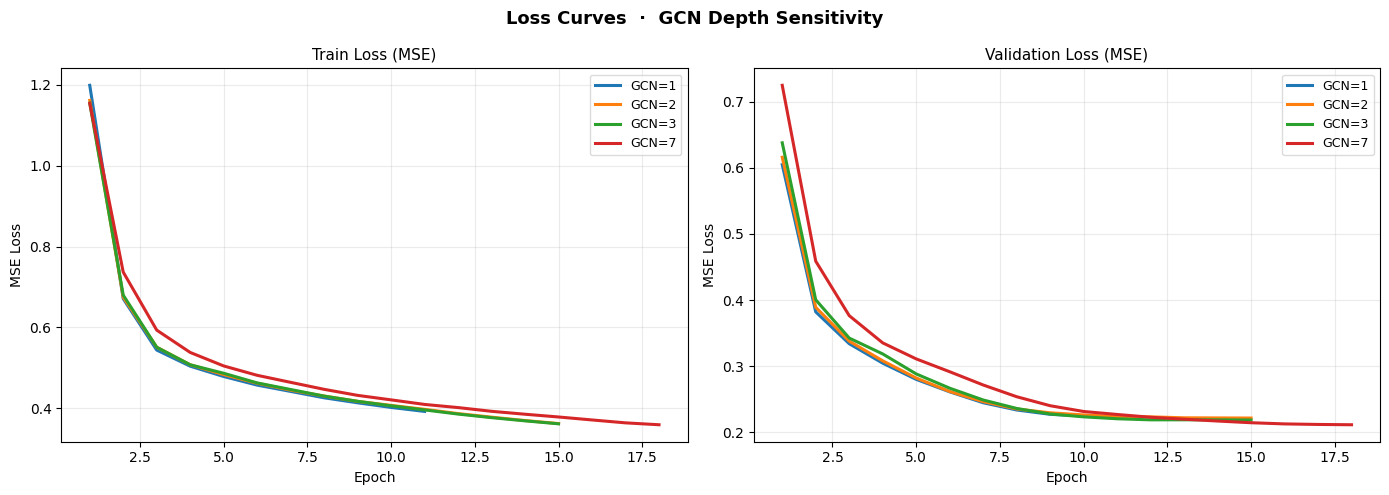

  📉 Saved: loss_curves_gcn_depth.png


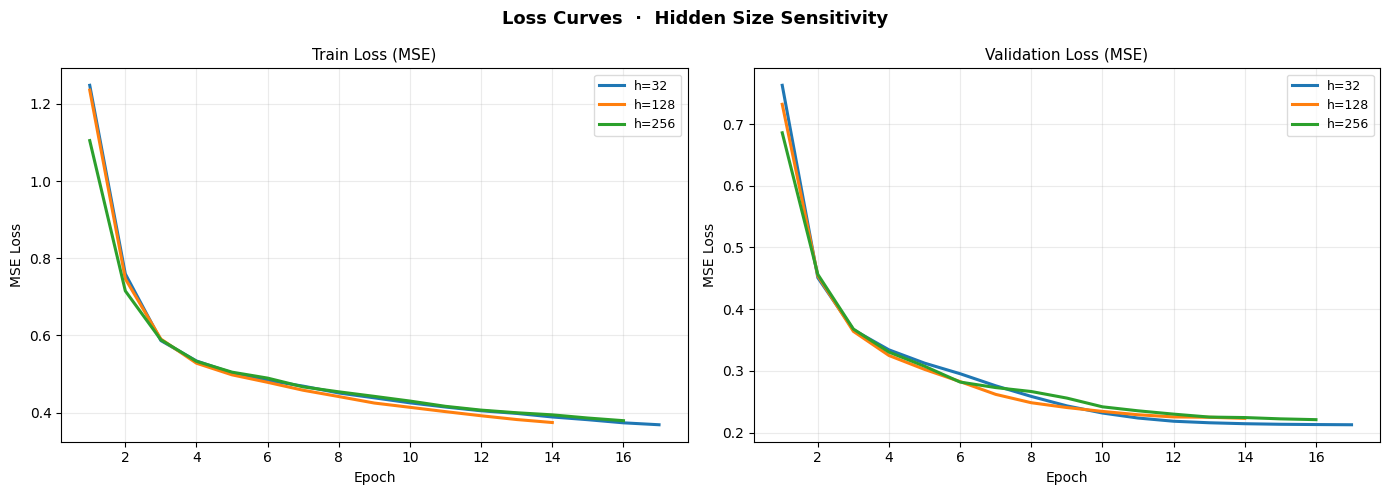

  📉 Saved: loss_curves_hidden_size.png


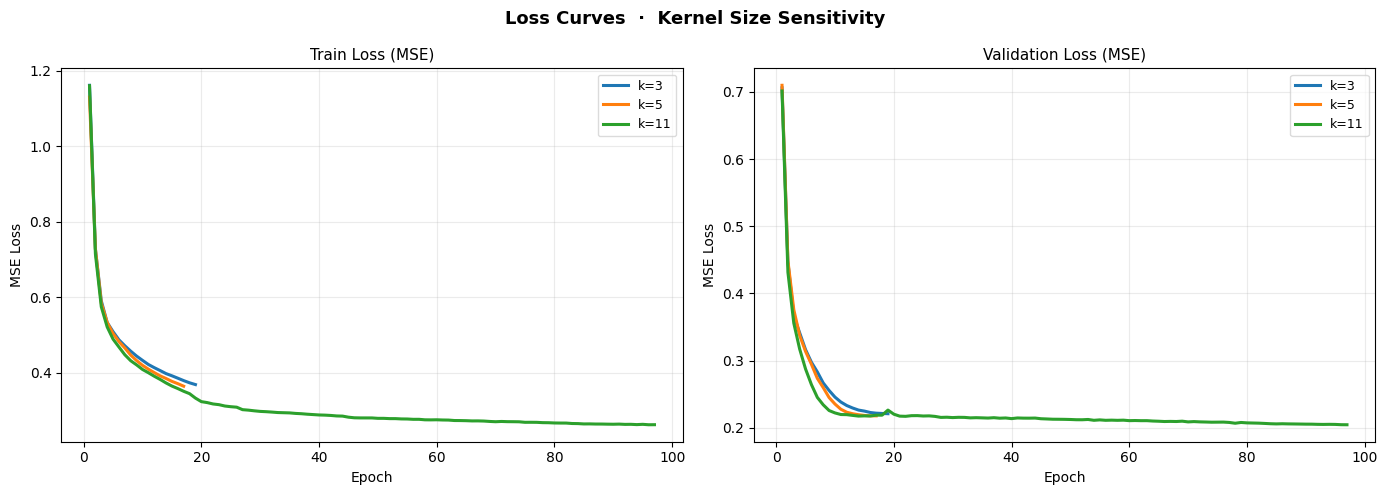

  📉 Saved: loss_curves_kernel_size.png


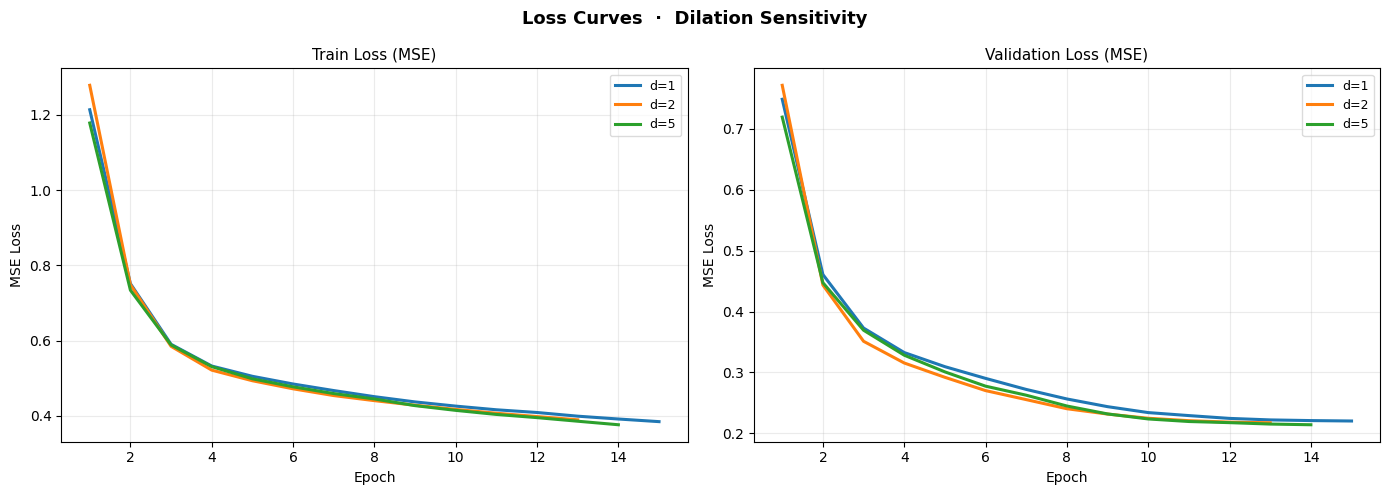

  📉 Saved: loss_curves_dilation.png


In [16]:
# ============================================================
# SENSITIVITY — Loss Curve Plots (one per sensitivity group)
# ============================================================
fig_dir = os.path.join(SAVE_DIR, "loss_curves")
os.makedirs(fig_dir, exist_ok=True)
GROUP_COLORS = plt.cm.tab10.colors

groups = {
    "GCN Depth":   {"gcn_depth_1": "GCN=1", "gcn_depth_2": "GCN=2",
                    "gcn_depth_3": "GCN=3", "gcn_depth_7": "GCN=7"},
    "Hidden Size": {"hidden_32": "h=32", "hidden_128": "h=128", "hidden_256": "h=256"},
    "Kernel Size": {"kernel_3": "k=3",  "kernel_5": "k=5",    "kernel_11": "k=11"},
    "Dilation":    {"dilation_1": "d=1","dilation_2": "d=2",  "dilation_5": "d=5"},
}

for group_name, cfg_label_map in groups.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    fig.suptitle(f"Loss Curves  ·  {group_name} Sensitivity", fontsize=13, fontweight="bold")

    for ax, loss_key, panel_title in zip(axes, ["train_losses", "val_losses"],
                                         ["Train Loss (MSE)", "Validation Loss (MSE)"]):
        for ci, (cfg_name, label) in enumerate(cfg_label_map.items()):
            r = ok_cfgs.get(cfg_name)
            if r is None: continue
            curve = r.get(loss_key, [])
            lw = 2.2 if r.get("beats_baseline") else 1.5
            ls = "-" if r.get("beats_baseline") else "--"
            ax.plot(range(1, len(curve)+1), curve,
                    color=GROUP_COLORS[ci % len(GROUP_COLORS)],
                    linewidth=lw, linestyle=ls, label=label)

        ax.set_xlabel("Epoch", fontsize=10)
        ax.set_ylabel("MSE Loss", fontsize=10)
        ax.set_title(panel_title, fontsize=11)
        ax.set_yscale("linear")
        ax.legend(fontsize=9, framealpha=0.7)
        ax.grid(True, which="both", alpha=0.25)

    plt.tight_layout()
    fname = f"loss_curves_{group_name.replace(' ','_').lower()}.png"
    fig.savefig(os.path.join(fig_dir, fname), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  📉 Saved: {fname}")

In [17]:
# Restore model_path entries for any OK result
for cfg_name, r in all_results.items():
    if r.get("status") != "OK":
        continue
    r["model_path"] = os.path.join(MODEL_SAVE_DIR, f"{cfg_name}_best_model.pth")

print("✅ model_path entries restored")

# Recompute beats_baseline with actual value
for r in all_results.values():
    if r.get("status") == "OK":
        r["beats_baseline"] = r["best_val_loss"] < BASELINE_VAL_LOSS

✅ model_path entries restored


In [18]:
BASELINE_VAL_LOSS

0.2206816729888612

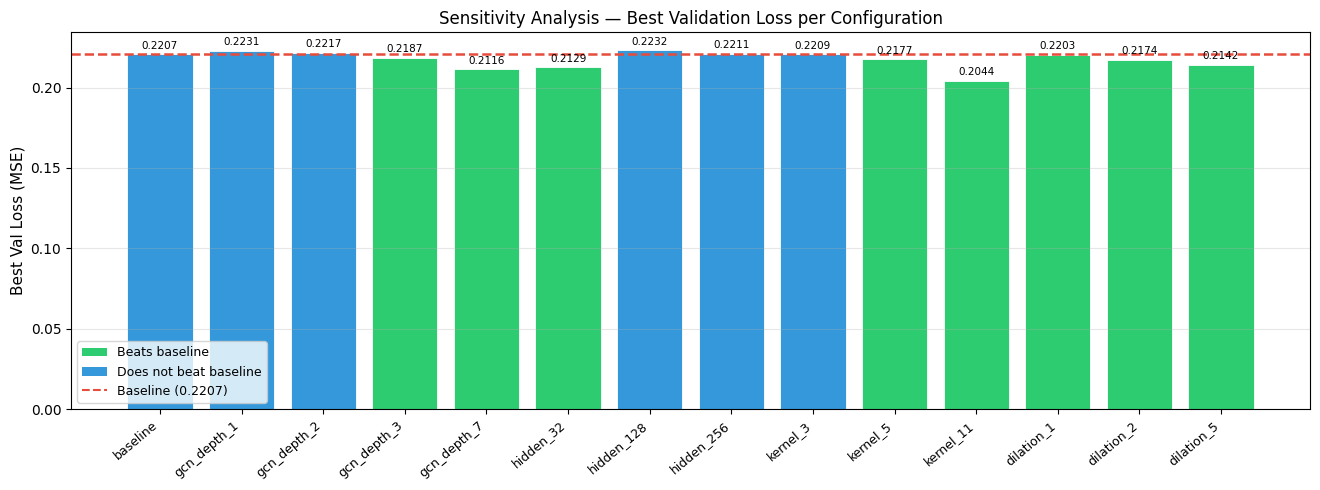

  📊 Saved: summary_val_loss_bar.png


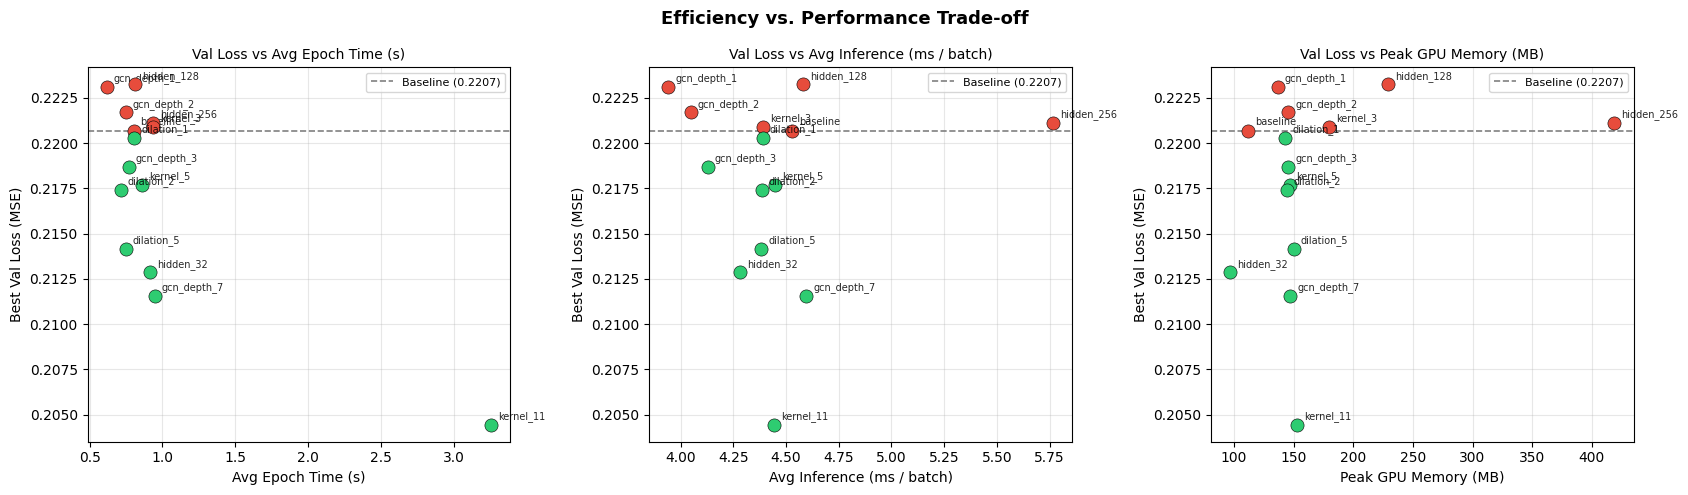

  📈 Saved: efficiency_scatter.png

✅ All outputs written to:  Sensitivity_Analysis_SH/
   📊  Excel  : sensitivity_analysis_results.xlsx
   📈  Figures: loss_curves/  (6 PNGs)

🏆 8 config(s) beat the baseline — models saved for XAI reuse:
   • gcn_depth_3          | Val 0.2187 | Sensitivity_Analysis_SH\best_models\gcn_depth_3_best_model.pth
   • gcn_depth_7          | Val 0.2116 | Sensitivity_Analysis_SH\best_models\gcn_depth_7_best_model.pth
   • hidden_32            | Val 0.2129 | Sensitivity_Analysis_SH\best_models\hidden_32_best_model.pth
   • kernel_5             | Val 0.2177 | Sensitivity_Analysis_SH\best_models\kernel_5_best_model.pth
   • kernel_11            | Val 0.2044 | Sensitivity_Analysis_SH\best_models\kernel_11_best_model.pth
   • dilation_1           | Val 0.2203 | Sensitivity_Analysis_SH\best_models\dilation_1_best_model.pth
   • dilation_2           | Val 0.2174 | Sensitivity_Analysis_SH\best_models\dilation_2_best_model.pth
   • dilation_5           | Val 0.2142 | Sen

In [19]:
# ============================================================
# SENSITIVITY — Bar Plot, Scatter Plots & Final Summary
# ============================================================
ok_items = [(k, v) for k, v in all_results.items() if v.get("status") == "OK"]

# ── 1. Summary Bar: Best Val Loss ──
if ok_items:
    names      = [k for k, _ in ok_items]
    val_losses = [v["best_val_loss"] for _, v in ok_items]
    bar_colors = ["#2ecc71" if v["beats_baseline"] else "#3498db" for _, v in ok_items]

    fig, ax = plt.subplots(figsize=(max(12, len(names) * 0.95), 5))
    bars = ax.bar(names, val_losses, color=bar_colors, edgecolor="white", linewidth=0.6)
    if BASELINE_VAL_LOSS < float("inf"):
        ax.axhline(BASELINE_VAL_LOSS, color="#e74c3c", linestyle="--",
                   linewidth=1.8, label=f"Baseline ({BASELINE_VAL_LOSS:.4f})")
    ax.set_ylabel("Best Val Loss (MSE)", fontsize=11)
    ax.set_title("Sensitivity Analysis — Best Validation Loss per Configuration", fontsize=12)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=40, ha="right", fontsize=9)
    ax.grid(True, axis="y", alpha=0.3)

    for bar, loss in zip(bars, val_losses):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f"{loss:.4f}", ha="center", va="bottom", fontsize=7.5)

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(facecolor="#2ecc71", label="Beats baseline"),
        Patch(facecolor="#3498db", label="Does not beat baseline"),
        plt.Line2D([0],[0], color="#e74c3c", linestyle="--", label=f"Baseline ({BASELINE_VAL_LOSS:.4f})"),
    ], fontsize=9)

    plt.tight_layout()
    fig.savefig(os.path.join(fig_dir, "summary_val_loss_bar.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("  📊 Saved: summary_val_loss_bar.png")

# ── 2. Efficiency Scatter: Val Loss vs Time/Mem ──
if ok_items:
    metrics_to_plot = [
        ("avg_epoch_time_s", "Avg Epoch Time (s)"),
        ("avg_inference_ms", "Avg Inference (ms / batch)"),
        ("peak_gpu_mem_mb",  "Peak GPU Memory (MB)"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle("Efficiency vs. Performance Trade-off", fontsize=13, fontweight="bold")

    for ax, (metric_key, xlabel) in zip(axes, metrics_to_plot):
        for cfg_name, r in ok_items:
            x = r.get(metric_key)
            y = r.get("best_val_loss")
            if x is None or y is None: continue
            color = "#2ecc71" if r["beats_baseline"] else "#e74c3c"
            ax.scatter(x, y, color=color, s=90, zorder=3, edgecolors="black", linewidth=0.4)
            ax.annotate(cfg_name, (x, y), textcoords="offset points",
                        xytext=(5, 4), fontsize=7, alpha=0.85)

        if BASELINE_VAL_LOSS < float("inf"):
            ax.axhline(BASELINE_VAL_LOSS, color="gray", linestyle="--",
                       linewidth=1.2, label=f"Baseline ({BASELINE_VAL_LOSS:.4f})")
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel("Best Val Loss (MSE)", fontsize=10)
        ax.set_title(f"Val Loss vs {xlabel}", fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig(os.path.join(fig_dir, "efficiency_scatter.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("  📈 Saved: efficiency_scatter.png")

# ── 3. Final Console Summary ──
print(f"\n{'='*64}")
print(f"✅ All outputs written to:  {SAVE_DIR}/")
print(f"   📊  Excel  : sensitivity_analysis_results.xlsx")
print(f"   📈  Figures: loss_curves/  ({4 + 2} PNGs)")
print(f"{'='*64}")

winners = [(k, v) for k, v in all_results.items() if v.get("beats_baseline")]
if winners:
    print(f"\n🏆 {len(winners)} config(s) beat the baseline — models saved for XAI reuse:")
    for k, v in winners:
        print(f"   • {k:20s} | Val {v['best_val_loss']:.4f} | {v['model_path']}")
else:
    print("\n  No config beat the baseline this run.")